# Project 2: Data and Statistical Reasoning
## Statistical Analysis of the UCI Adult (Census Income) Dataset

**Name:** Timothy

**Dataset:** UCI Machine Learning Repository — [Adult / Census Income Data Set](https://archive.ics.uci.edu/dataset/2/adult) (`adult_income.csv`, derived from `adult.data`)

**Why this dataset:** The Adult dataset contains 32,561 rows and 15 columns extracted from 1994 U.S. Census Bureau data, well above the 500-row / 6-column minimum for this project. It includes numeric variables (`age`, `hours_per_week`, `capital_gain`, `capital_loss`, `education_num`, `fnlwgt`) and categorical/grouping variables (`workclass`, `education`, `marital_status`, `occupation`, `relationship`, `race`, `sex`, `native_country`, `income`), which makes it well suited to descriptive statistics, visualization, and hypothesis testing (for example, comparing `hours_per_week` or `age` across `income` or `sex` groups). It is a real, publicly available dataset (not synthetic) and is unrelated to the Iris dataset used in Project 1.

**Project description:** This notebook loads the Adult dataset, explores it with descriptive statistics and visualizations, and uses hypothesis testing to investigate whether variables such as age, education, and hours worked per week are associated with income level. The goal is to practice a complete, reproducible statistical workflow: load, describe, visualize, test, and interpret.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", None)

## Data Ingestion

The dataset has no header row in its raw form, uses `?` for missing categorical values, and has a leading space after each comma. `adult_income.csv` was pre-processed from the raw `adult.data` file to add a header row and strip that extra whitespace; the `?` placeholders are kept as-is here and inspected below.

In [2]:
df = pd.read_csv("adult_income.csv")
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns\n")
df.info()

Shape: 32561 rows x 15 columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


**Column types confirmed:** `age`, `fnlwgt`, `education_num`, `capital_gain`, `capital_loss`, and `hours_per_week` loaded as numeric (`int64`). `workclass`, `education`, `marital_status`, `occupation`, `relationship`, `race`, `sex`, `native_country`, and `income` loaded as categorical text (`object`), which is correct for each column's meaning.

## Descriptive Statistics

In [4]:
numeric_cols = ["age", "education_num", "capital_gain", "capital_loss", "hours_per_week", "fnlwgt"]
categorical_cols = ["workclass", "education", "marital_status", "occupation",
                     "relationship", "race", "sex", "native_country", "income"]

df[numeric_cols].describe()

,age,education_num,capital_gain,capital_loss,hours_per_week,fnlwgt
count,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,3.256100e+04
mean,38.581647,10.080679,1077.648844,87.303830,40.437456,1.897784e+05
std,13.640433,2.572720,7385.292085,402.960219,12.347429,1.055500e+05
min,17.000000,1.000000,0.000000,0.000000,1.000000,1.228500e+04
25%,28.000000,9.000000,0.000000,0.000000,40.000000,1.178270e+05
50%,37.000000,10.000000,0.000000,0.000000,40.000000,1.783560e+05
75%,48.000000,12.000000,0.000000,0.000000,45.000000,2.370510e+05
max,90.000000,16.000000,99999.000000,4356.000000,99.000000,1.484705e+06


**What this reveals:** The typical worker in this dataset is around 38-39 years old and works close to 40 hours per week (the median and 75th percentile both sit at or near 40, showing how standard the full-time work week is). `capital_gain` and `capital_loss` are heavily skewed — their medians are 0, but the maximums (99,999 and 4,356) are far above the mean, meaning only a small minority of people report any capital gains or losses at all. `education_num` ranges from 1 to 16, consistent with it being a numeric encoding of degree level rather than a freeform measurement.

In [5]:
for col in categorical_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()

--- workclass ---
workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

--- education ---
education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64

--- marital_status ---
marital_status
Married-civ-spouse       14976
Never-married            10683
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64

--- occupation ---
occ

**What this reveals:** The dataset is imbalanced on `income`: roughly 3 out of 4 people earn `<=50K`, so any comparison between income groups is comparing a large group to a smaller one. `workclass`, `occupation`, and `native_country` each contain a `?` category representing missing/unreported values, with `native_country` overwhelmingly dominated by `United-States`. `sex` is also imbalanced (about two-thirds `Male`), which is worth keeping in mind when comparing groups later, since group sizes differ substantially.

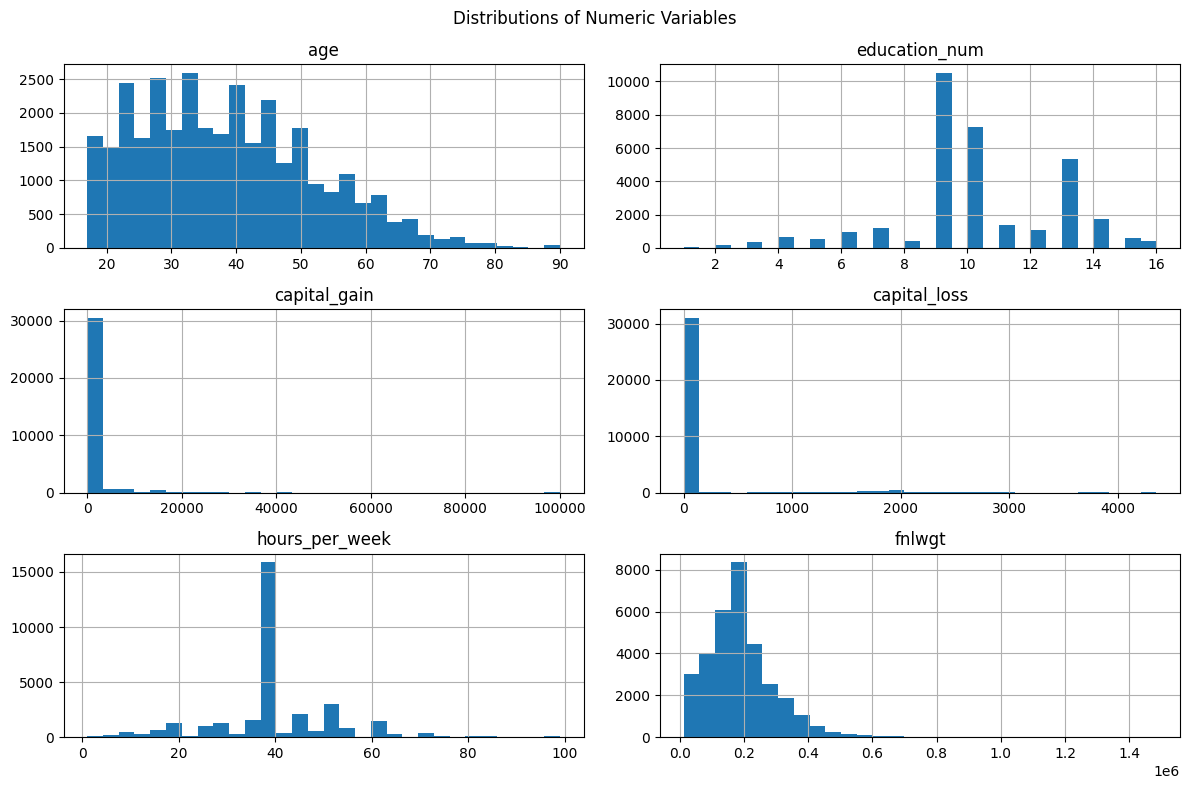

In [6]:
df[numeric_cols].hist(figsize=(12, 8), bins=30)
plt.suptitle("Distributions of Numeric Variables")
plt.tight_layout()
plt.show()

**What this reveals:** `age` is right-skewed with most people between roughly 20 and 50 years old. `hours_per_week` is heavily concentrated at 40, the standard full-time work week, with smaller spikes at round numbers like 20, 45, and 60. `capital_gain` and `capital_loss` are dominated by zero, confirming the skew seen in the summary statistics above — most people report no capital gains or losses in a given year.

## Visual Models

**Analytical question:** Do people who earn more than $50K per year tend to work more hours per week, and how does that relate to other patterns in the data (education, and the relationships among the numeric variables)? The three visual models below approach this from different angles: a boxplot comparing the two income groups directly, a bar chart showing how the *share* of high earners changes with education, and a correlation heatmap showing how all the numeric variables relate to one another.

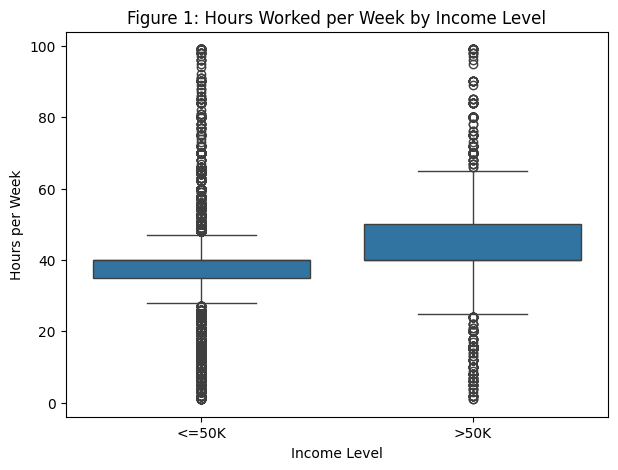

In [7]:
# Visual Model 1: Boxplot of hours worked per week by income level
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="income", y="hours_per_week", order=["<=50K", ">50K"])
plt.title("Figure 1: Hours Worked per Week by Income Level")
plt.xlabel("Income Level")
plt.ylabel("Hours per Week")
plt.show()

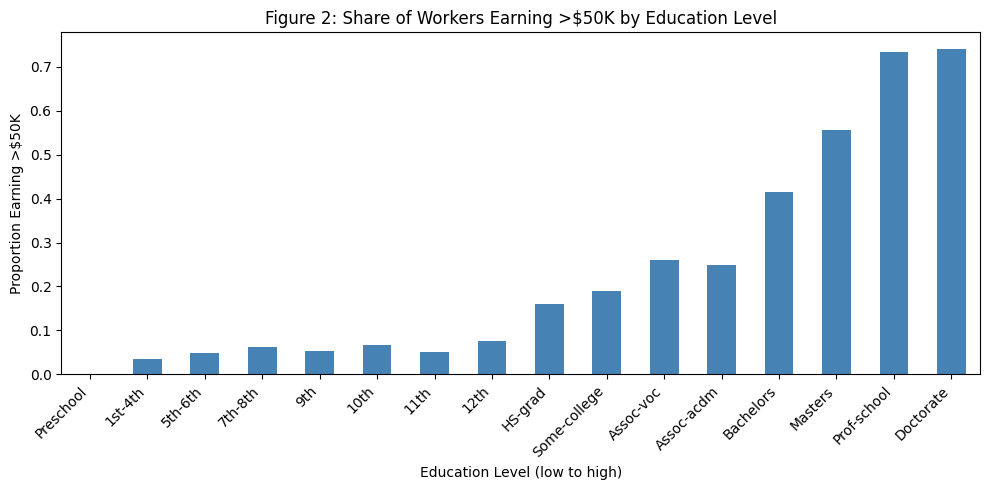

In [8]:
# Visual Model 2: Bar chart of share earning >50K by education level
education_order = (
    df[["education", "education_num"]]
    .drop_duplicates()
    .sort_values("education_num")["education"]
)
share_above_50k = (
    df.assign(is_high_income=(df["income"] == ">50K").astype(int))
    .groupby("education")["is_high_income"]
    .mean()
    .reindex(education_order)
)

plt.figure(figsize=(10, 5))
share_above_50k.plot(kind="bar", color="steelblue")
plt.title("Figure 2: Share of Workers Earning >$50K by Education Level")
plt.xlabel("Education Level (low to high)")
plt.ylabel("Proportion Earning >$50K")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

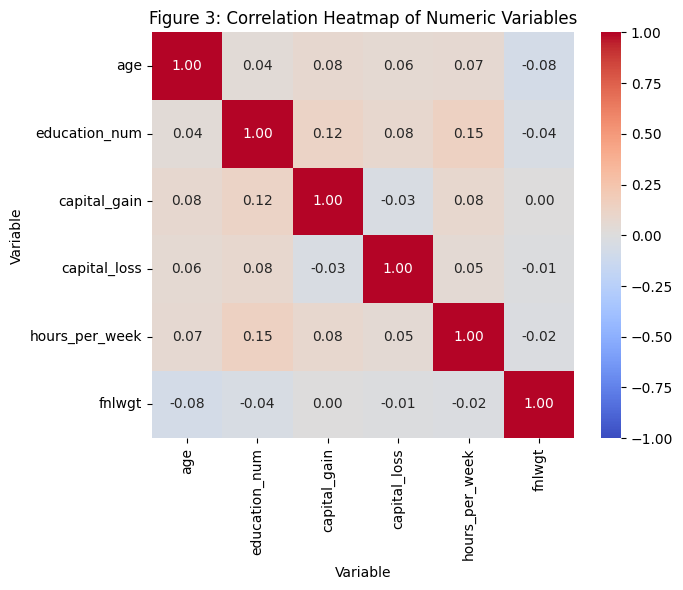

In [9]:
# Visual Model 3: Correlation heatmap of numeric variables
plt.figure(figsize=(7, 6))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Figure 3: Correlation Heatmap of Numeric Variables")
plt.xlabel("Variable")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

**Comparing the three visual models:**

- **Figure 1 (boxplot)** shows that people earning `>50K` have a noticeably higher median and mean `hours_per_week` (mean ≈ 45.5) than people earning `<=50K` (mean ≈ 38.8), with the `>50K` group's box shifted upward and its lower whisker higher as well. This is the most direct visual evidence for the analytical question, since it compares the exact two groups and the exact variable the hypothesis test below examines.
- **Figure 2 (bar chart)** shows a strong, almost monotonic increase in the share of high earners as education rises — from 0% among `Preschool` graduates to about 41.5% for `Bachelors`, 55.7% for `Masters`, and roughly 73-74% for `Prof-school` and `Doctorate` holders. This reveals that education is a much stronger dividing line for income than hours worked alone, and suggests hours worked and education may act together rather than independently.
- **Figure 3 (correlation heatmap)** shows that none of the numeric variables are strongly linearly correlated with each other — the strongest relationship involving `hours_per_week` is with `education_num` (r ≈ 0.15), which is still weak. This tells us that any income differences in hours worked are unlikely to be explained by a simple linear relationship with the other numeric variables captured here.

**Which model best supports the analytical question:** Figure 1 (the boxplot) is the most directly relevant, since the analytical question is specifically about whether `hours_per_week` differs by `income`, and the boxplot compares exactly those two variables. Figure 2 provides important supporting context (education matters more than hours), and Figure 3 confirms that this relationship isn't simply a byproduct of correlated numeric variables.

## Hypothesis Test

**Question:** Do people earning `>50K` per year work a different average number of hours per week than people earning `<=50K`?

**Null hypothesis (H0):** The mean `hours_per_week` is the same for the `<=50K` and `>50K` income groups (μ₁ = μ₂).

**Alternative hypothesis (H1):** The mean `hours_per_week` differs between the `<=50K` and `>50K` income groups (μ₁ ≠ μ₂).

**Test chosen:** A two-sample (independent groups) t-test, using Welch's version (`equal_var=False`) because the two income groups have very different sample sizes (24,720 vs 7,841) and, as seen in Figure 1, different spreads. Significance level: α = 0.05.

In [10]:
group_low = df.loc[df["income"] == "<=50K", "hours_per_week"]
group_high = df.loc[df["income"] == ">50K", "hours_per_week"]

t_stat, p_value = stats.ttest_ind(group_high, group_low, equal_var=False)

print(f"Group sizes: <=50K n={len(group_low)}, >50K n={len(group_high)}")
print(f"Mean hours_per_week: <=50K = {group_low.mean():.2f}, >50K = {group_high.mean():.2f}")
print(f"Welch's t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4e}")

Group sizes: <=50K n=24720, >50K n=7841
Mean hours_per_week: <=50K = 38.84, >50K = 45.47
Welch's t-statistic: 45.1231
p-value: 0.0000e+00


**Result:** The p-value is far below α = 0.05, so we reject the null hypothesis. Full interpretation of this result is provided in `Statistical_Analysis_Report.pdf`.

## Summary

This notebook explored the UCI Adult (Census Income) dataset, focusing on whether hours worked per week and education level relate to whether someone earns more than $50K per year. Descriptive statistics showed a strongly imbalanced income variable and heavily skewed capital-gain/capital-loss columns, while the visual models revealed that higher earners work more hours on average and that the share of high earners rises sharply with education, especially beyond a Bachelor's degree. One unexpected finding was how weak the correlations were among the numeric variables overall (all below 0.16), which means the income/hours relationship is not simply riding on some other correlated variable. A challenge was handling the dataset's `?` placeholders for missing `workclass`, `occupation`, and `native_country` values, which needed to be recognized as missing data rather than a valid category before drawing conclusions. The Welch's t-test comparing hours worked between income groups produced a statistically significant result, which is interpreted in full in the accompanying PDF report.